In [1]:
from src.experiments import utils

## Experiment 1
We divide Hyperplane into two distinct regions (A and B)
Concept drift will occur periodically, but only within region B

Purpose: test, whether C-DES can isolate drift adaptation to the affected cluster while maintaining high accuracy in cluster A

Initializing Experiment 1: Regional Concept Drift...
Processing stream...
Processed 2500 samples...
Processed 5000 samples...
Processed 7500 samples...
Processed 10000 samples...
Experiment complete. Generating plots...


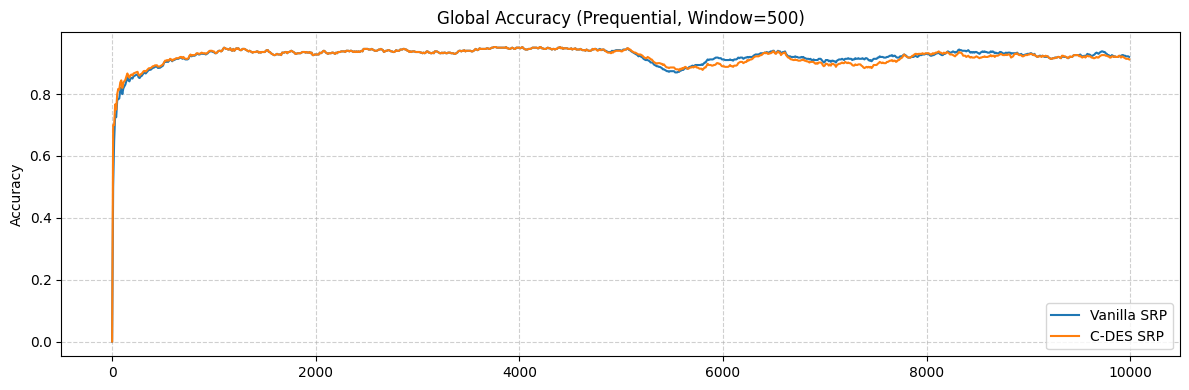

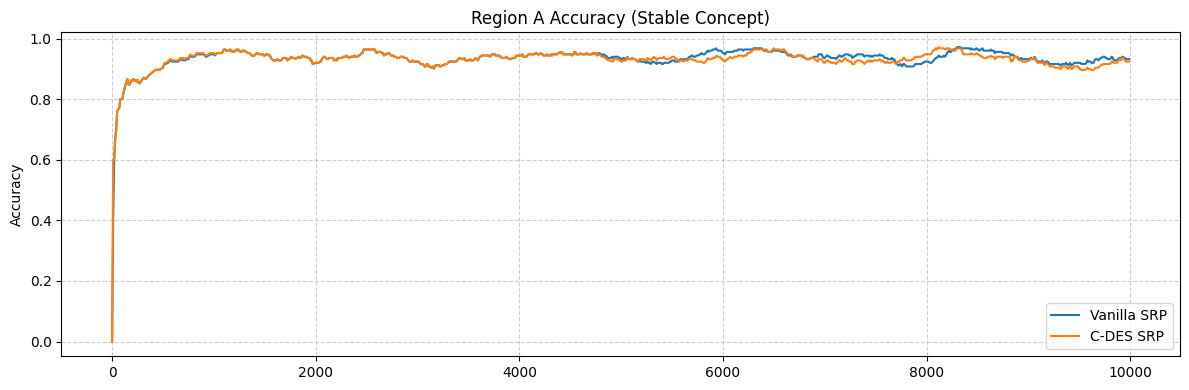

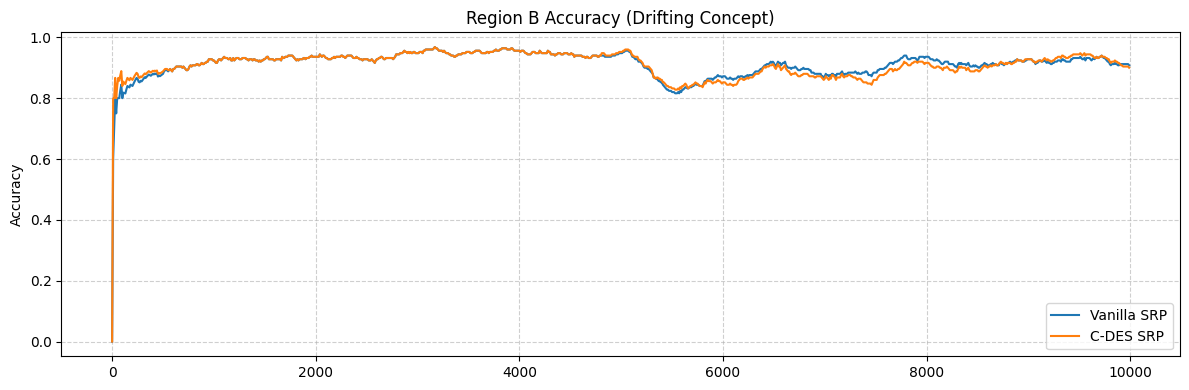

In [2]:
utils.run_experiment_1()

## Experiment 2: Contextual Sensor Failure
We simulate an IoT/sensor environment where the decision boundary completely flips, but only under a specific environmental condition (e.g., "High Temperature").
The alternative condition ("Low Temperature") remains stable throughout the entire stream.

Purpose: Test resistance to catastrophic forgetting by seeing if the ensemble can silence models only in the failing context, preserving its learned logic for the healthy context.

Initializing Experiment 2: Contextual Sensor Drift...
Processing stream...
Processed 2500 samples...
Processed 5000 samples...
Processed 7500 samples...
Processed 10000 samples...
Experiment complete. Generating plots...


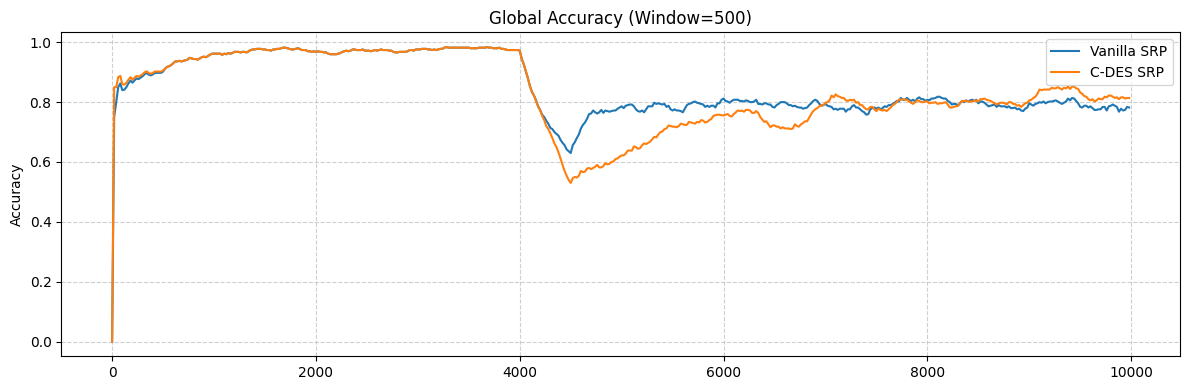

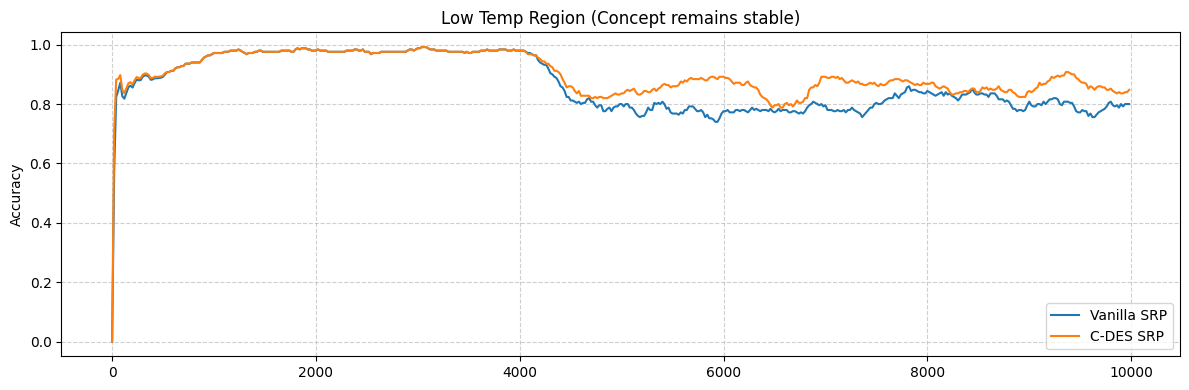

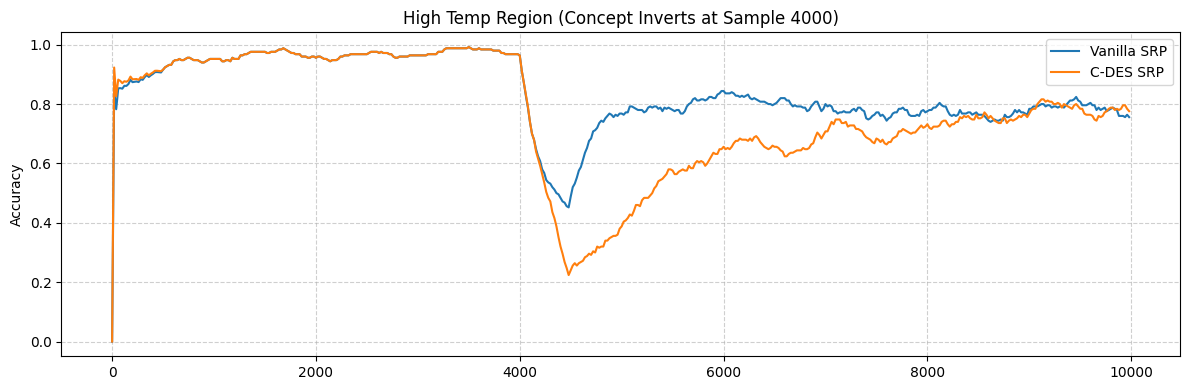

In [3]:
# Run Experiment 2
utils.run_experiment_2()

## Experiment 3: Recurrent Drift (A -> B -> A)
We transition the stream from Concept A, to Concept B, and then revert back to Concept A.
The phases are long enough for the ensemble to fully adapt to each new concept.

Purpose: Evaluate long-term ensemble memory and the "Soft Reset" mechanism to see if C-DES instantly recovers its baseline accuracy when Concept A returns, bypassing the relearning curve.

Initializing Experiment 3: Recurrent Drift (A -> B -> A)...
Processing stream...
Processed 3000 samples...
Processed 6000 samples...
Processed 9000 samples...
Processed 12000 samples...
Processed 15000 samples...
Experiment complete. Generating plot...


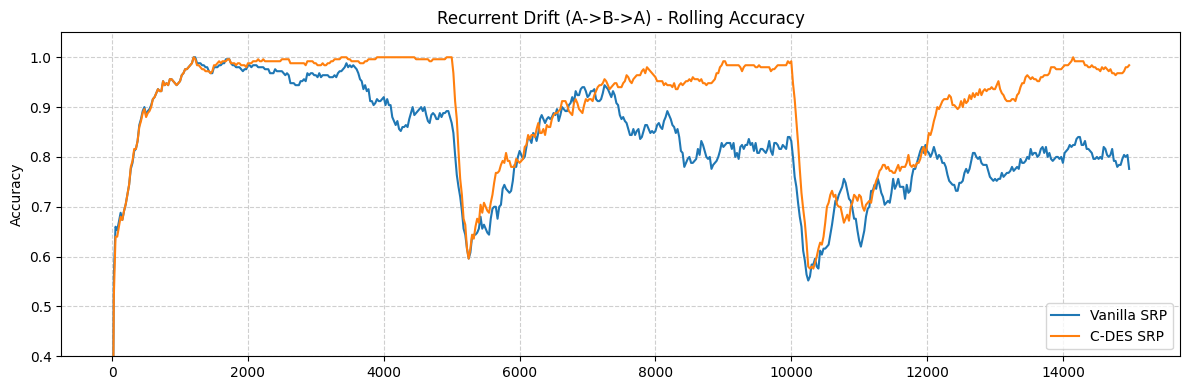

In [4]:
# Run Experiment 3
utils.run_experiment_3()

## Experiment 4: Rapid Concept Flickering
We rapidly alternate the data stream between two opposing concepts at a high frequency (e.g., every 250 samples).
This switching happens too fast for standard drift detectors like ADWIN to confidently log a change and rebuild trees.

Purpose: Test the responsiveness of the dynamic selection threshold, proving C-DES acts as an agile switching ensemble without relying on a formal, lagging drift signal.

Initializing Experiment 4: Rapid Concept Flickering...
Processing stream...
Processed 2500 samples...
Processed 5000 samples...
Processed 7500 samples...
Processed 10000 samples...
Experiment complete. Generating plots...


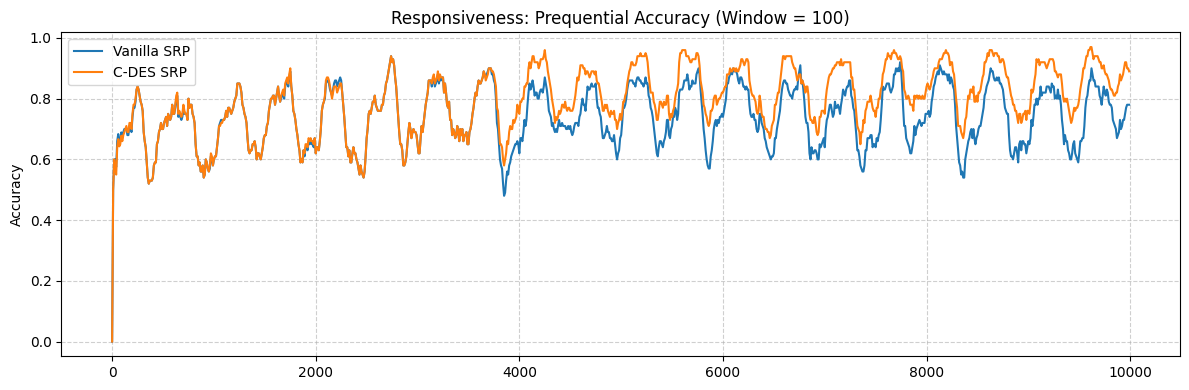

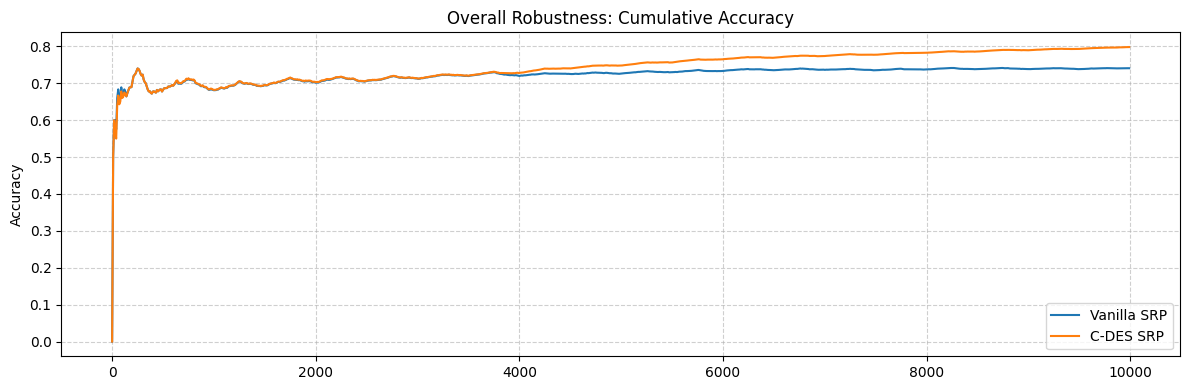

In [5]:
# Run Experiment 4
utils.run_experiment_4()

# Experiment 5: Sensitivity to Cluster Count (k)
We evaluate C-DES across a highly complex, 4-state multi-context stream using varying numbers of predefined clusters (k = 2, 4, 8, 20).
We track both cumulative accuracy and computational latency (ms/sample).

Purpose: Map the hyperparameter "sweet spot" and prove "Ensemble Overfitting" by showing that arbitrarily high values of k fragment the data too thinly and cause latency spikes.

Initializing Experiment 5: Hyperparameter Sensitivity (Cluster Count k)...
Processing stream and measuring latency...
Processed 2500 samples...
Processed 5000 samples...
Processed 7500 samples...
Processed 10000 samples...
Experiment complete. Generating plots...


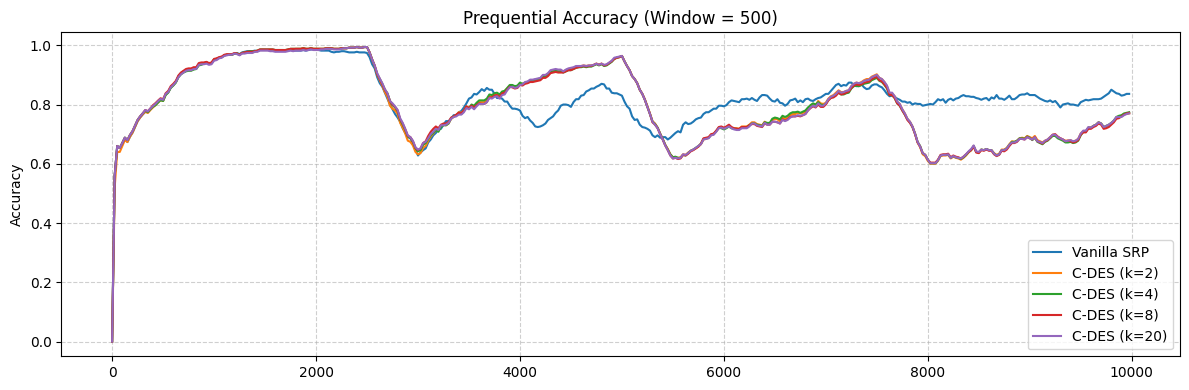

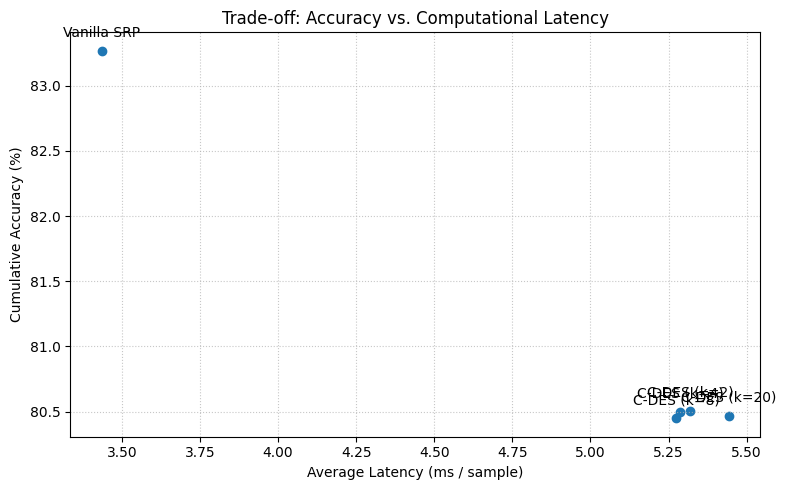

In [6]:
# Run Experiment 5
utils.run_experiment_5()

## Experiment 6: The "Noise Curse" (Dimensionality)
We wrap a standard synthetic stream (Agrawal) and inject progressively larger amounts of completely irrelevant, random continuous features (0, 10, 50, 100).

Purpose: Establish the breaking point of the C-DES architecture by testing the vulnerability of the KMeans context-mapping phase to the "Curse of Dimensionality" compared to Vanilla SRP.

Initializing Experiment 6: The Curse of Dimensionality (Noise Injection)...

--- Testing with 0 injected noise features ---
Processed 2500 samples...
Processed 5000 samples...
Vanilla SRP Final Acc: 83.08%
C-DES SRP Final Acc: 97.28%

--- Testing with 10 injected noise features ---
Processed 2500 samples...
Processed 5000 samples...
Vanilla SRP Final Acc: 87.02%
C-DES SRP Final Acc: 92.16%

--- Testing with 50 injected noise features ---
Processed 2500 samples...
Processed 5000 samples...
Vanilla SRP Final Acc: 66.09%
C-DES SRP Final Acc: 67.27%

--- Testing with 100 injected noise features ---
Processed 2500 samples...
Processed 5000 samples...
Vanilla SRP Final Acc: 65.65%
C-DES SRP Final Acc: 65.59%

Experiment complete. Generating plot...


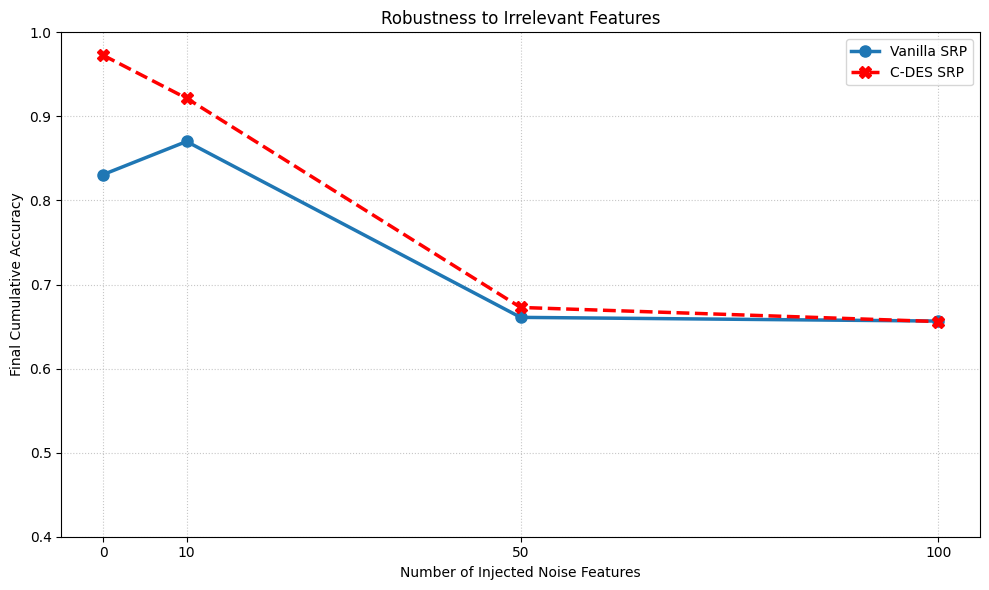

In [7]:
# Run Experiment 6
utils.run_experiment_6()

## Experiment 7: Standard Synthetic Benchmarks
We run classic stream learning benchmarks (SEA, Agrawal) featuring exclusively global concept drifts.
C-DES is benchmarked against the gold standards of the field: Adaptive Random Forest (ARF), Hoeffding Adaptive Tree (HAT), and Vanilla SRP.

Purpose: Test broad generalization by proving that the architectural overhead of C-DES does not degrade its foundational ability to compete with global ensembles on standard tasks.

Initializing Experiment 7: Standard Synthetic Benchmarks (SEA)...
Processing stream...
Processed 10000 samples (Concept Drift Triggered)...
Processed 20000 samples (Concept Drift Triggered)...
Processed 30000 samples (Concept Drift Triggered)...
Processed 40000 samples (Concept Drift Triggered)...

Experiment complete. Generating plot and summary table...


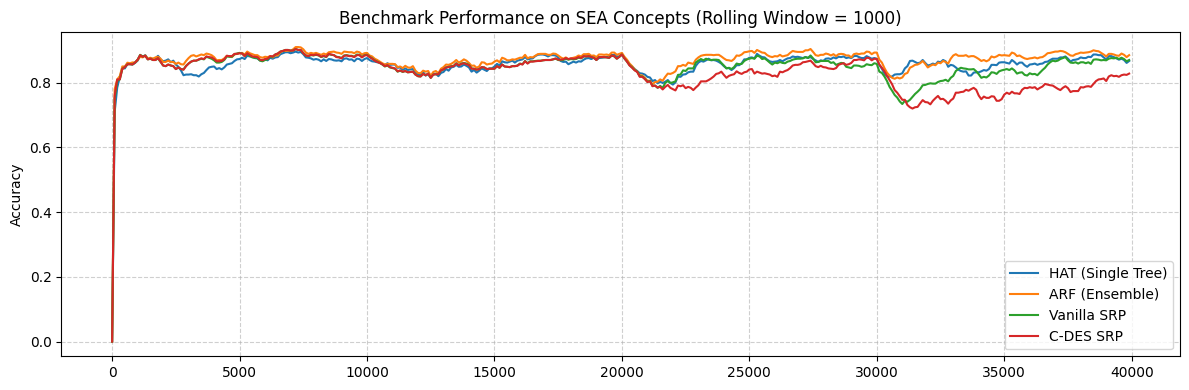

            Model Accuracy (%) Cohen's Kappa Latency (ms/sample)
HAT (Single Tree)       85.97%        0.6962                0.14
   ARF (Ensemble)       87.41%        0.7272                1.29
      Vanilla SRP       85.35%        0.6787                2.65
        C-DES SRP       83.45%        0.6371                3.24


In [8]:
# Run Experiment 7
utils.run_experiment_7()

## Experiment 8: Real-World Stream Performance
We evaluate the models on noisy, unstructured real-world datasets (Electricity Pricing, Phishing Website Detection).
These datasets lack clean, predefined drift boundaries.

Purpose: Test practical, real-world viability and precisely quantify the absolute latency penalty (ms/sample) introduced by computing KMeans distances on every incoming instance.

In [2]:
# Run Experiment 8
utils.run_experiment_8()

Initializing Experiment 8: Real-World Benchmarks...

--- Evaluating on: Phishing Website Detection (1250 samples) ---
  Processed 312/1250 samples...
  Processed 624/1250 samples...
  Processed 936/1250 samples...
  Processed 1248/1250 samples...
Finished Phishing Website Detection.

--- Evaluating on: Electricity Pricing (15000 samples) ---
  Processed 3750/15000 samples...
  Processed 7500/15000 samples...
  Processed 11250/15000 samples...
  Processed 15000/15000 samples...
Finished Electricity Pricing.

All streams processed. Generating plots and tables...
                   Dataset       Model Final Accuracy Latency (ms/sample)
       Electricity Pricing Vanilla SRP         88.99%             3.09 ms
       Electricity Pricing   C-DES SRP         88.04%             3.71 ms
Phishing Website Detection Vanilla SRP         91.19%             2.14 ms
Phishing Website Detection   C-DES SRP         91.03%             2.16 ms


## Experiment 9: Deactivation Strategy Ablation
We run an ablation study on a highly polarized stream where concepts actively conflict.
C-DES is tested against an "ablated" version of itself where the dynamic deactivation threshold (setting weights to 0.0) is turned off.

Purpose: Prove the mathematical necessity of the "Better-than-Random" deactivation rule by demonstrating that explicitly silencing "confused" models acts as a vital noise filter.

Initializing Experiment 9: Ablation Study - The Value of Dynamic Deactivation...
Processing stream...
Processed 3000 samples...
Processed 6000 samples...
Processed 9000 samples...
Processed 12000 samples...
Experiment complete. Generating plots...


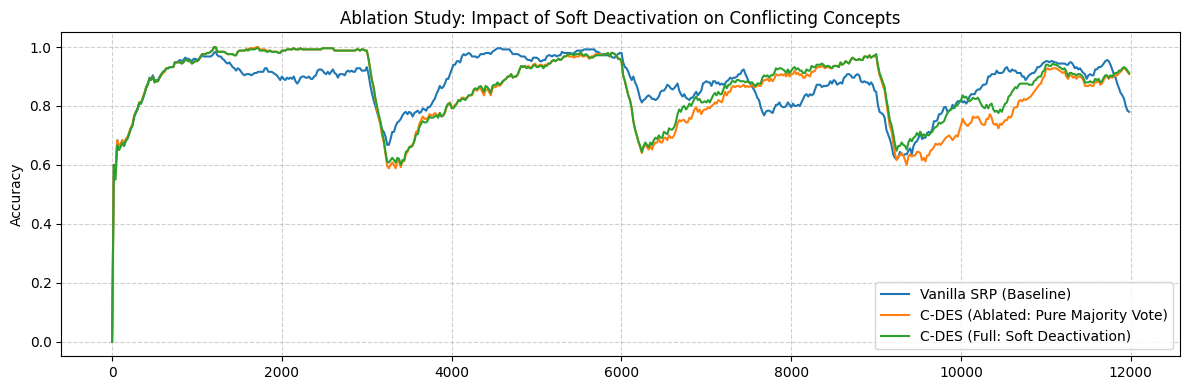

In [10]:
# Run Experiment 9
utils.run_experiment_9()

## Experiment 10: Ensemble Churn and Collateral Damage
We simulate a multi-region environment where one specific region suddenly breaks and begins broadcasting pure random noise.
We track accuracy on the stable regions alongside the cumulative number of drift detection triggers fired by the ensemble.

Purpose: Validate the drift reaction mechanism by proving that localizing the drift signal (via Soft Resets) quarantines bad data, preventing the "Ensemble Churn" seen in global detectors.

Initializing Experiment 10: The Quarantine Effect (Ensemble Churn)...
Processing stream...
Processed 3000 samples...
Processed 6000 samples...
Processed 9000 samples...
Processed 12000 samples...
Experiment complete. Generating plots...


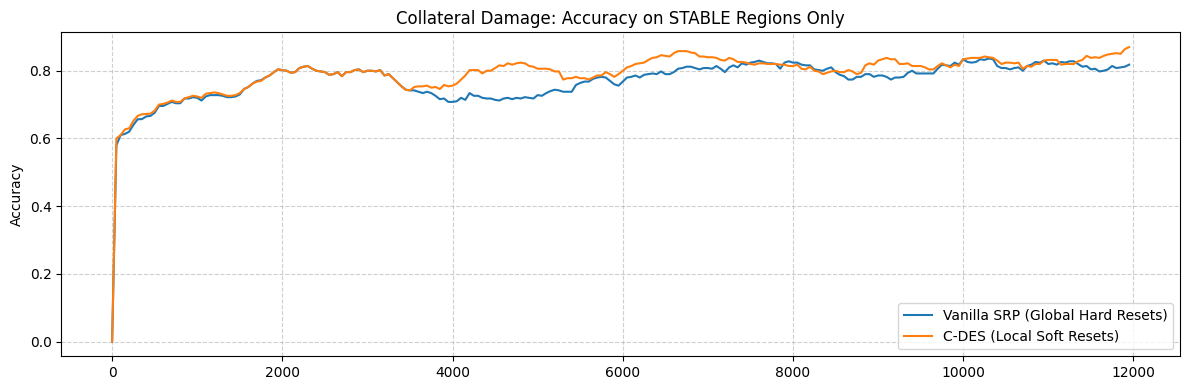

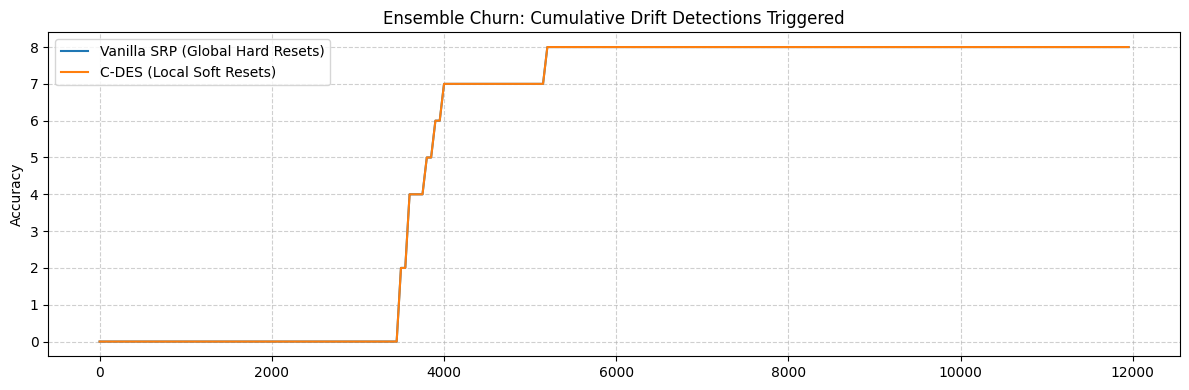

In [11]:
# Run Experiment 10
utils.run_experiment_10()